# Fase CRISP-DM: Carga, Exploración Informática e Imputación Inteligente
**Plataforma**: AgroData Intelligence Platform (AgroStatsApp)  
**Propósito**: Este notebook carga los 10 conjuntos de datos agropecuarios desde `data/RAW`, ejecuta un perfilamiento informático exhaustivo (nulos, duplicados, metadatos, granularidad) y aplica el motor de imputación inteligente multivariada bajo el marco de Rubin.

In [12]:
# 1. Configuración de Entorno e Importación de Módulos
import sys
import os
from pathlib import Path

def setup_environment():
    """Configura dinámicamente sys.path para entorno local (Windows/Linux) y Google Colab."""
    # A. Soporte para Google Colab
    if "google.colab" in sys.modules:
        colab_repo = Path("/content/Statsfirm")
        if not colab_repo.exists():
            import subprocess
            subprocess.run(["git", "clone", "https://github.com/adansanchezc1-spec/Statsfirm.git", "/content/Statsfirm"], check=True)
        colab_src = colab_repo / "AgroStats AndTech" / "AgroStatsApp" / "src"
        if colab_src.exists() and str(colab_src) not in sys.path:
            sys.path.insert(0, str(colab_src))
            return str(colab_src)

    # B. Detección dinámica en Entorno Local
    candidates = [
        Path(r"c:\Users\ADAN\OneDrive\Documentos\Statsfirm\AgroStats AndTech\AgroStatsApp\src"),
        Path.cwd() / "src",
        Path.cwd() / "AgroStats AndTech" / "AgroStatsApp" / "src",
        Path.cwd().parent / "src",
        Path.cwd().parent.parent / "src",
        Path.cwd().parent.parent / "AgroStats AndTech" / "AgroStatsApp" / "src",
    ]
    
    # Búsqueda hacia arriba en el árbol de directorios
    curr = Path.cwd().resolve()
    for _ in range(6):
        target = curr / "AgroStats AndTech" / "AgroStatsApp" / "src"
        if target.exists() and (target / "notebook_code").is_dir():
            candidates.insert(0, target)
            break
        curr = curr.parent

    for c in candidates:
        if c.exists() and (c / "notebook_code").is_dir():
            resolved = str(c.resolve())
            if resolved not in sys.path:
                sys.path.insert(0, resolved)
            return resolved

    return None

setup_environment()

# Importación correcta: desde notebook_code directamente
from notebook_code import (
    RawDataLoader,
    DatasetProfiler,
    NotebookImputerBridge,
    load_all_raw_datasets,
    load_raw_dataset,
    explore_dataset,
)

print("✓ Módulos de notebook_code importados exitosamente.")


✓ Módulos de notebook_code importados exitosamente.


In [13]:
# 2. Carga Automatizada de los 10 Datasets desde data/RAW
datasets = load_all_raw_datasets()

print(f'Total de datasets cargados desde data/RAW: {len(datasets)}\n')
for name, df in datasets.items():
    print(f'• {name:25} -> {df.shape[0]:5} filas x {df.shape[1]:2} columnas')

Total de datasets cargados desde data/RAW: 10

• dane_ipc                  ->    25 filas x 25 columnas
• dane_ipp                  ->    47 filas x  3 columnas
• ideam_evapotranspiracion  ->   200 filas x 24 columnas
• ideam_pluvio              ->   200 filas x 12 columnas
• ideam_radiacion           ->   169 filas x 20 columnas
• ideam_sequia              ->   200 filas x 24 columnas
• ideam_temperatura         ->   200 filas x 12 columnas
• sipsa_abastecimientos     ->    10 filas x  2 columnas
• sipsa_insumos             ->    92 filas x 58 columnas
• sipsa_precios             ->    45 filas x 29 columnas


In [14]:
# 3. Selección y Exploración Informática de un Dataset (ej. Pluviometría IDEAM)
df_pluvio = datasets['ideam_pluvio']

# Diagnóstico informático en formato estructurado
perfil = explore_dataset(df_pluvio, dataset_name='IDEAM Pluviometría')

print('=== METADATOS Y CONTEXTO ===')
for k, v in perfil['metadata'].items():
    print(f'  {k}: {v}')

print('\n=== ANÁLISIS DE DATOS NULOS Y AUSENCIAS ===')
print(f"  Tasa global de nulos: {perfil['missingness']['global_missing_rate_pct']} %")
print(f"  Filas completas: {perfil['missingness']['complete_rows_count']} ({perfil['missingness']['complete_rows_pct']} %)")
print(f"  Columnas con nulos: {perfil['missingness']['columns_with_missing']}")

print('\n=== DUPLICADOS Y CLAVES CANDIDATAS ===')
print(f"  Filas duplicadas: {perfil['duplication']['exact_duplicate_rows']} ({perfil['duplication']['duplicate_rate_pct']} %)")
print(f"  Claves candidatas (100% únicas): {perfil['duplication']['unique_key_candidates']}")

print('\n=== GRANULARIDAD TEMPORAL Y ESPACIAL ===')
print('  Temporal:', perfil['granularity']['temporal_features'])
print('  Espacial:', list(perfil['granularity']['spatial_features'].keys()))

=== METADATOS Y CONTEXTO ===
  dataset_name: IDEAM Pluviometría
  total_rows: 200
  total_columns: 12
  memory_mb: 0.09
  numeric_columns_count: 5
  categorical_columns_count: 7
  datetime_columns_count: 1

=== ANÁLISIS DE DATOS NULOS Y AUSENCIAS ===
  Tasa global de nulos: 0.0 %
  Filas completas: 200 (100.0 %)
  Columnas con nulos: []

=== DUPLICADOS Y CLAVES CANDIDATAS ===
  Filas duplicadas: 0 (0.0 %)
  Claves candidatas (100% únicas): []

=== GRANULARIDAD TEMPORAL Y ESPACIAL ===
  Temporal: {'fechaobservacion': {'min_date': '2020-03-11 00:00:00', 'max_date': '2020-03-11 23:50:00', 'total_days_span': 0, 'unique_dates': 124}}
  Espacial: ['codigoestacion', 'nombreestacion', 'departamento', 'municipio', 'latitud', 'longitud']


In [15]:
# 4. Tabla de Perfilamiento Detallado Columna por Columna
tabla_resumen = DatasetProfiler.profile_table(df_pluvio)
display(tabla_resumen)

,Columna,Tipo,No_Nulos,Nulos,%_Nulos,Valores_Únicos,Detalle_Estadístico
0,codigoestacion,int64,200,0,0.0,165,"Media=344882129.19, Std=884565719.79, Rango=[1..."
1,codigosensor,int64,200,0,0.0,1,"Media=240.0, Std=0.0, Rango=[240.0 : 240.0]"
2,fechaobservacion,object,200,0,0.0,124,Moda='2020-03-11T06:0...' (2.5%)
3,valorobservado,float64,200,0,0.0,6,"Media=0.02, Std=0.16, Rango=[0.0 : 2.0]"
4,nombreestacion,object,200,0,0.0,164,Moda='PTO VALDIVIA...' (2.0%)
5,departamento,object,200,0,0.0,31,Moda='CUNDINAMARCA...' (9.5%)
6,municipio,object,200,0,0.0,142,Moda='ATACO...' (2.0%)
7,zonahidrografica,object,200,0,0.0,24,Moda='CAUCA...' (22.0%)
8,latitud,float64,200,0,0.0,165,"Media=5.46, Std=2.45, Rango=[0.81 : 11.53]"
9,longitud,float64,200,0,0.0,164,"Media=-74.8, Std=1.49, Rango=[-77.49 : -70.73]"


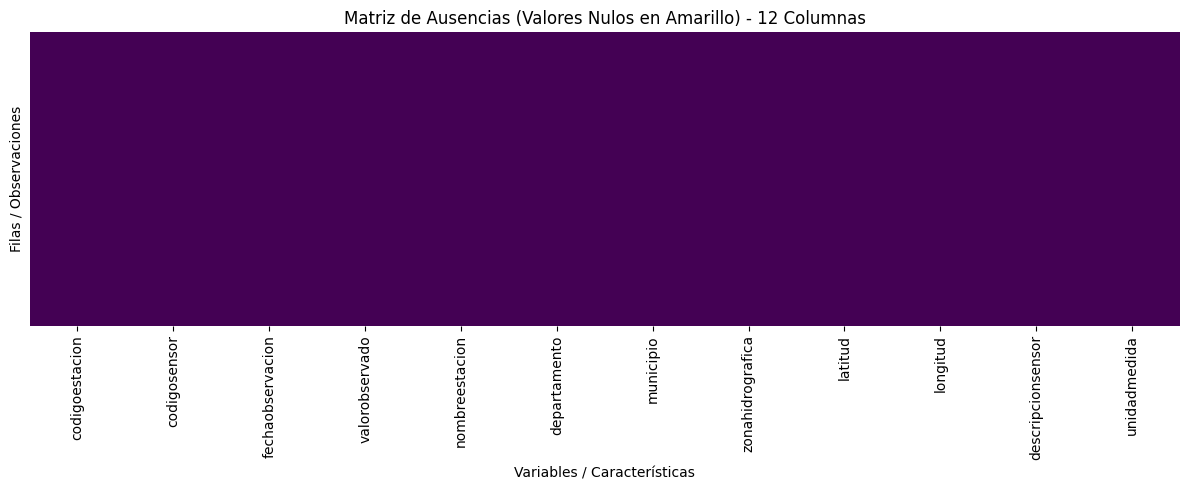

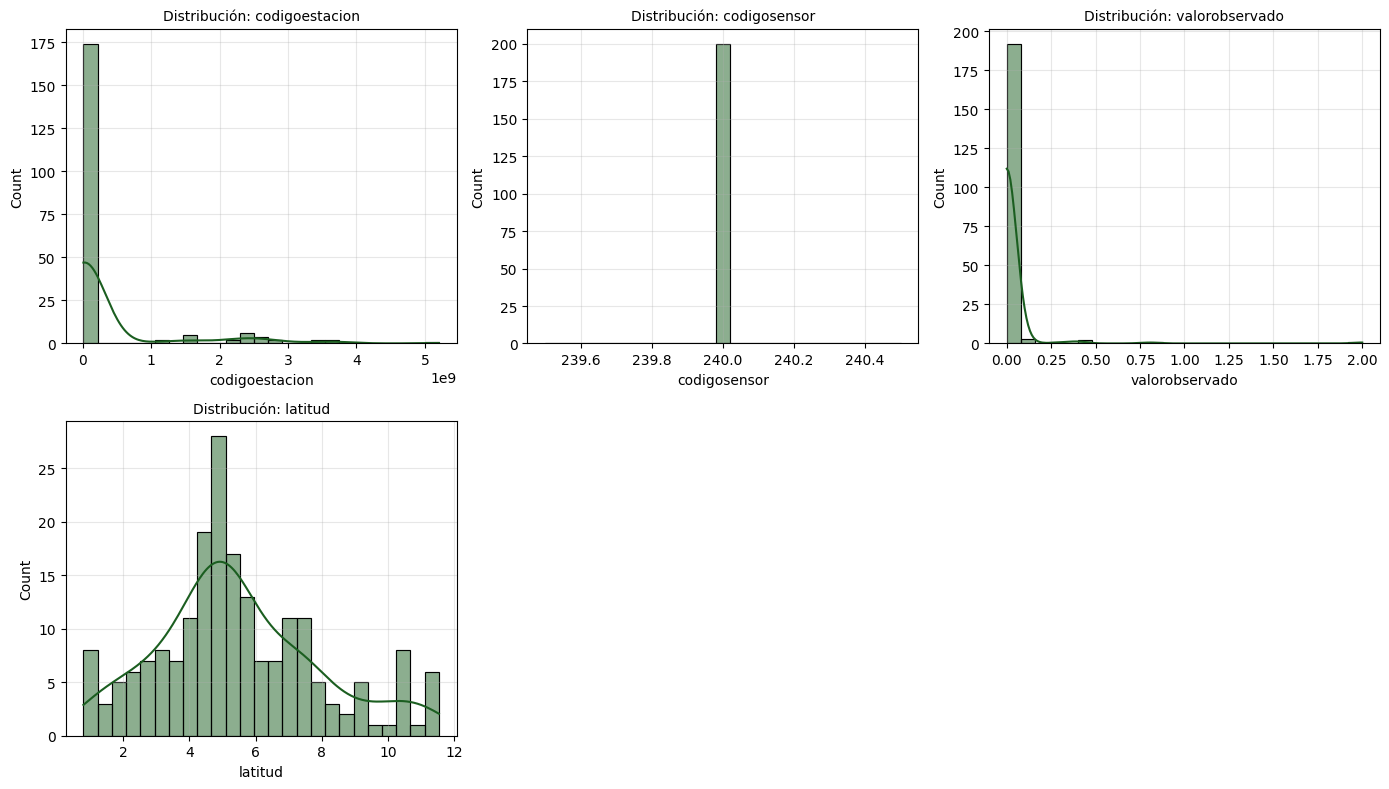

In [16]:
# 5. Visualizaciones Diagnósticas (Matriz de Ausencias e Histogramas)
fig_missing = DatasetProfiler.plot_missingness_heatmap(df_pluvio)
fig_missing.show()

fig_dist = DatasetProfiler.plot_distributions(df_pluvio, max_features=4)
if fig_dist:
    fig_dist.show()

In [18]:
# 6. Motor de Imputación Inteligente (Diagnóstico Rubin + Torneo Competitivo)
bridge = NotebookImputerBridge(variance_penalty_weight=1.5)

# Seleccionar dataset a evaluar:
# Nota: 'ideam_pluvio' está 100% completo (0 nulos).
# Para apreciar el torneo competitivo completo con ausencias reales, usa datasets['sipsa_insumos'] o datasets['sipsa_precios'].
target_df = datasets.get('sipsa_insumos', df_pluvio)
target_name = 'sipsa_insumos' if 'sipsa_insumos' in datasets else 'ideam_pluvio'

print(f"Evaluando dataset: {target_name} ({target_df.shape[0]} filas x {target_df.shape[1]} columnas)")

# 1. Diagnóstico estadístico del mecanismo de pérdida (Rubin & Little)
diagnostico = bridge.diagnose(target_df)
print(f"• Mecanismo diagnosticado: {diagnostico.diagnosed_mechanism}")
print(f"• Estrategia recomendada:  {diagnostico.recommended_strategy}")
if diagnostico.littles_test_p_value is not None:
    print(f"• P-value Test de Little: {diagnostico.littles_test_p_value:.5f}")

# 2. Torneo competitivo de algoritmos con penalización de varianza
df_imputado, tabla_benchmark, resultado = bridge.run_benchmark(target_df)

print("\n=== RESULTADOS DEL BENCHMARK COMPETITIVO ===")
display(tabla_benchmark)

if resultado.winning_algorithm_name == "NO_IMPUTATION_NEEDED":
    print("\nℹ [INFO] El dataset ya cuenta con integridad completa. No se requirió imputación.")
else:
    print(f"\n✓ Algoritmo ganador: {resultado.winning_algorithm_name} (Score: {resultado.winning_score:.4f})")
    print(f"✓ Banderas de auditoría inyectadas: {resultado.audit_flags_injected}")


Evaluando dataset: sipsa_insumos (92 filas x 58 columnas)
• Mecanismo diagnosticado: MNAR_OR_STRONG_MAR
• Estrategia recomendada:  MICE_WITH_FLAG
• P-value Test de Little: 0.00000

=== RESULTADOS DEL BENCHMARK COMPETITIVO ===


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Algoritmo,Score_Torneo (RMSE x Varianza),Seleccionado_Ganador
0,Interpolation_linear,3.6630,✓ Ganador
1,KNN_k5,5.9658,
2,MICE_BayesianRidge,6.1839,
3,ConditionalGroupMedian,68.8512,



✓ Algoritmo ganador: Interpolation_linear (Score: 3.6630)
✓ Banderas de auditoría inyectadas: ['total_otros_is_imputed', '_impute_method']


In [19]:
# 7. Comparación de Distribución y Preservación de Varianza
numeric_cols = df_pluvio.select_dtypes(include=['number']).columns.tolist()
if numeric_cols:
    col_to_check = numeric_cols[0]
    fig_comp = NotebookImputerBridge.plot_imputation_comparison(
        original_df=df_pluvio,
        imputed_df=df_imputado,
        feature_col=col_to_check
    )
    if fig_comp:
        fig_comp.show()